Lab 7 - K-nearest neighbor

Oscar Ramos

Logan Cheng

Alexis Velasquez

Data Set: Machine Learning for Diabetes with Python

https://www.kaggle.com/datasets/rahulsah06/machine-learning-for-diabetes-with-python/data

In [ ]:
#Importing the required libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import (train_test_split,
                                     cross_val_score)
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import (accuracy_score,
                             classification_report,
                             confusion_matrix)

In [ ]:
#load dataset
df=pd.read_csv("diabetes_data.csv")

print("Dataset Overview")
print(df.head())
print(df.shape)
df

Dataset Overview
   Pregnancies  Glucose  BloodPressure  SkinThickness  Insulin   BMI  \
0            6      148             72             35        0  33.6   
1            1       85             66             29        0  26.6   
2            8      183             64              0        0  23.3   
3            1       89             66             23       94  28.1   
4            0      137             40             35      168  43.1   

   DiabetesPedigreeFunction  Age  Outcome  
0                     0.627   50        1  
1                     0.351   31        0  
2                     0.672   32        1  
3                     0.167   21        0  
4                     2.288   33        1  
(768, 9)


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1
...,...,...,...,...,...,...,...,...,...
763,10,101,76,48,180,32.9,0.171,63,0
764,2,122,70,27,0,36.8,0.340,27,0
765,5,121,72,23,112,26.2,0.245,30,0
766,1,126,60,0,0,30.1,0.349,47,1


In [ ]:
#changes the names of the x and y columns to simpler ones

print(df.rename(columns={'Pregnancies':'Preg', 'Glucose':'Gluc', 'BloodPressure':'BP', 'SkinThickness':'ST', 'Insulin':'Ins', 'DiabetesPedigreeFunction':'DPF'}, inplace=True))
df

None


,Preg,Gluc,BP,ST,Ins,BMI,DPF,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1
...,...,...,...,...,...,...,...,...,...
763,10,101,76,48,180,32.9,0.171,63,0
764,2,122,70,27,0,36.8,0.340,27,0
765,5,121,72,23,112,26.2,0.245,30,0
766,1,126,60,0,0,30.1,0.349,47,1


In [ ]:
#seperate features from labels, all columns except the label
x=df.drop('Outcome', axis=1)
y=df['Outcome']

print("X shape:", x.shape)
print("y shape:", y.shape)

X shape: (768, 8)
y shape: (768,)


In [ ]:
# Split: 80% training, 20% testing
# stratify=y ensures each age group is proportionally represented
# in both the training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training size:", X_train.shape)
print("Testing size:", X_test.shape)

Training size: (614, 8)
Testing size: (154, 8)


In [ ]:
# Remember: fit_transform on training, transform on testing!
scaler=StandardScaler()
X_train_scaled=scaler.fit_transform(X_train)
X_test_scaled=scaler.transform(X_test)

print("Data scaled successfully")

Data scaled successfully


In [ ]:
# Create and train the model
knn=KNeighborsClassifier(n_neighbors=7)
knn.fit(X_train_scaled, y_train)

# Make predictions
y_pred=knn.predict(X_test_scaled)

In [ ]:
#accuracy
accuracy=accuracy_score(y_test, y_pred)
print(f"Overall Accuracy: {accuracy:.2%}")
print()

Overall Accuracy: 74.68%



In [ ]:
# Print Classification Report
print("Classification Report:")
print(classification_report(y_test, y_pred))

Classification Report:
              precision    recall  f1-score   support

           0       0.79      0.84      0.81       100
           1       0.66      0.57      0.61        54

    accuracy                           0.75       154
   macro avg       0.72      0.71      0.71       154
weighted avg       0.74      0.75      0.74       154



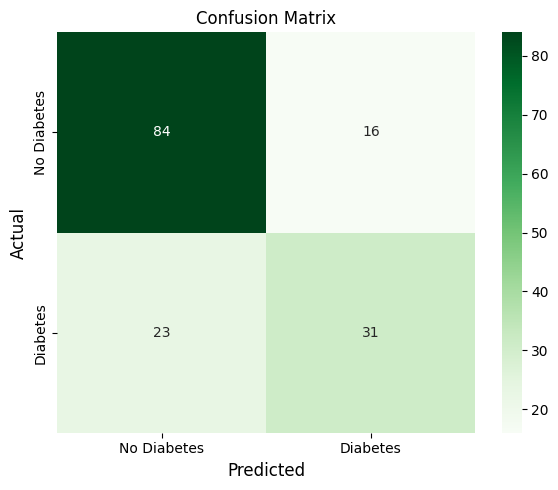

In [ ]:
# Create confusion matrix
cm = confusion_matrix(
    y_test, y_pred)

# Plot heatmap
plt.figure(figsize=(6,5))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Greens',
    xticklabels=['No Diabetes', 'Diabetes'],
    yticklabels=['No Diabetes', 'Diabetes']
)

plt.xlabel('Predicted', fontsize=12)
plt.ylabel('Actual', fontsize=12)
plt.title('Confusion Matrix', fontsize=12)
plt.tight_layout()
plt.savefig('Diabetes_data.png', dpi=150)
plt.show()

   K= 1 → CV Accuracy = 71.33% (±1.26%)
   K= 5 → CV Accuracy = 73.29% (±2.21%)
   K=10 → CV Accuracy = 74.92% (±1.06%)
   K=15 → CV Accuracy = 74.76% (±2.09%)
   K=20 → CV Accuracy = 74.76% (±1.46%)
   K=25 → CV Accuracy = 75.08% (±2.82%)
   K=30 → CV Accuracy = 75.74% (±2.23%)



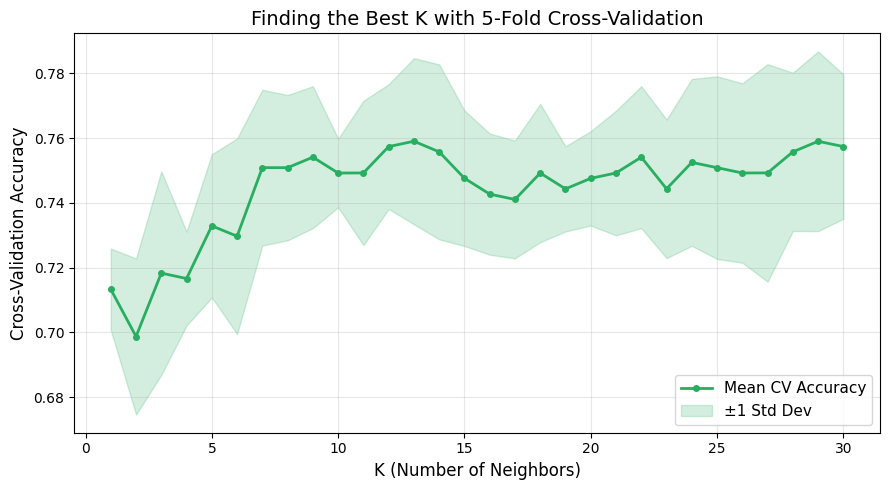

   -> Best K = 13
   -> Best CV Accuracy = 75.90%
   -> Chart saved as 'diabetes_best_k.png'



In [ ]:
# Test K 1 to 31
k_range = range(1, 31)

cv_means = []
cv_stds = []

for k in k_range:
  # Create a model with this K
  model = KNeighborsClassifier(n_neighbors=k)

  # Run a 5-fold cross-validation on the TRAINING data only
  # Cross_val_score returns an array of a 5 accuracy scores
  scores = cross_val_score(
      model,
      X_train_scaled,
      y_train,
      cv=5,
      scoring='accuracy'
  )

  # Store the meand and standard deviation
  cv_means.append(scores.mean())
  cv_stds.append(scores.std())

  if k % 5 == 0 or k == 1:
    print(f"   K={k:2d} → CV Accuracy = {scores.mean():.2%} (±{scores.std():.2%})")

print()

# Plot the results
plt.figure(figsize=(9, 5))


# Convert to numpy arrays
cv_means = np.array(cv_means)
cv_stds = np.array(cv_stds)
k_list = list(k_range)

# Main line (mean accuracy)
plt.plot(k_list, cv_means, marker='o', color='#27ae60',
         linewidth=2, markersize=4, label='Mean CV Accuracy')

# Shaded region (±1 standard deviation)
# This shows the UNCERTAINTY in our accuracy estimate)
plt.fill_between(
    k_list,
    cv_means - cv_stds,     # Lower bound
    cv_means + cv_stds,     # Upper bound
    alpha=0.2,              # Transparency
    color='#27ae60',        # Same green
    label='±1 Std Dev'
)

plt.xlabel('K (Number of Neighbors)', fontsize=12)
plt.ylabel('Cross-Validation Accuracy', fontsize=12)
plt.title('Finding the Best K with 5-Fold Cross-Validation', fontsize=14)
plt.legend(fontsize=11)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('diabetes_best_k.png', dpi=150)
plt.show()

#find the best k
best_k = k_list[np.argmax(cv_means)]
best_cv_accuracy = cv_means.max()

print(f"   -> Best K = {best_k}")
print(f"   -> Best CV Accuracy = {best_cv_accuracy:.2%}")
print(f"   -> Chart saved as 'diabetes_best_k.png'")
print()

In [ ]:
# Retrain with the best K
final_model = KNeighborsClassifier(n_neighbors=best_k)
final_model.fit(X_train_scaled, y_train)

# Final predictions on the test set
y_pred_final = final_model.predict(X_test_scaled)

# Final accuracy
final_accuracy = accuracy_score(y_test, y_pred_final)
print(f"Final Test Accuracy (K={best_k}): {final_accuracy:.2%}")
print()

# Final classification report
print("Final Classification Report:")
print(classification_report(y_test, y_pred_final))

Final Test Accuracy (K=13): 75.97%

Final Classification Report:
              precision    recall  f1-score   support

           0       0.79      0.85      0.82       100
           1       0.68      0.59      0.63        54

    accuracy                           0.76       154
   macro avg       0.74      0.72      0.73       154
weighted avg       0.75      0.76      0.76       154



In [ ]:
# Three new patient data
new_data = pd.DataFrame({
    'Preg': [2, 5, 1],
    'Gluc': [120, 150, 95],
    'BP': [70, 95, 50],
    'ST': [25, 30, 20],
    'Ins': [75, 130, 70],
    'BMI': [28.5, 35.5, 22.5],
    'DPF': [0.5, 0.5, 0.8],
    'Age': [25, 35, 45]
})

print("New Patient Data:")
print(new_data.to_string(index=False))
print()

new_scaled = scaler.transform(new_data)

# Get predictions and probabilities
predictions = final_model.predict(new_scaled)
probabilities = final_model.predict_proba(new_scaled)

# Display the results for each mobile device
class_labels = final_model.classes_

for i in range(len(new_data)):
  print(f"Patient #{i+1}:")
  print(f" Predicted outcome: {predictions[i]}")
  print(f" Confidence breakdown:")

  for cls, prob in zip(class_labels, probabilities[i]):

        # Visual bar to make probabilities easier to read
        bar_length = int(prob * 25)
        bar = '█' * bar_length + '░' * (25 - bar_length)
        print(f"      {str(cls):8s} {bar} {prob:6.1%}")
  print()

New Patient Data:
 Preg  Gluc  BP  ST  Ins  BMI  DPF  Age
    2   120  70  25   75 28.5  0.5   25
    5   150  95  30  130 35.5  0.5   35
    1    95  50  20   70 22.5  0.8   45

Patient #1:
 Predicted outcome: 0
 Confidence breakdown:
      0        ███████████████████████░░  92.3%
      1        █░░░░░░░░░░░░░░░░░░░░░░░░   7.7%

Patient #2:
 Predicted outcome: 0
 Confidence breakdown:
      0        █████████████░░░░░░░░░░░░  53.8%
      1        ███████████░░░░░░░░░░░░░░  46.2%

Patient #3:
 Predicted outcome: 0
 Confidence breakdown:
      0        █████████████████████████ 100.0%
      1        ░░░░░░░░░░░░░░░░░░░░░░░░░   0.0%



In this lab, we used a KNN model to predict whether a patient has diabetes based on different health factors like glucose, blood pressure, and BMI. We started by loading and cleaning the dataset, renaming some columns to make them easier to work with, and then splitting the data into training and testing sets. After scaling the data, we trained the KNN model and evaluated how well it performed using accuracy, a classification report, and a confusion matrix.
We also tested different K values (from 1 to 30) using cross-validation to figure out which one works best. After finding the optimal K, we retrained the model and checked the final accuracy. At the end, we used the model to predict outcomes for new patient data and looked at the probabilities to see how confident the model was in each prediction.